In [1]:
import os
import numpy as np
from netCDF4 import Dataset


# -----------------------------
# Your ANUGA .tms writer (unchanged)
# -----------------------------
def create_tms_manually(file_path, times, discharges):
    """Creates a NetCDF .tms file with cleaned metadata."""
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    with Dataset(file_path, 'w', format='NETCDF4') as rootgrp:
        rootgrp.createDimension('time', len(times))

        t_var = rootgrp.createVariable('time', 'f8', ('time',))
        q_var = rootgrp.createVariable('discharge', 'f8', ('time',))

        t_var[:] = times
        q_var[:] = discharges

        # Standard ANUGA NetCDF attributes
        rootgrp.description = "Manual conversion for ANUGA"
        rootgrp.starttime = 0.0
        rootgrp.xllcorner = 0.0
        rootgrp.yllcorner = 0.0
        rootgrp.zone = -1
        rootgrp.projection = "UTM"
        rootgrp.datum = "WGS84"


# -----------------------------
# Split 1000 scenarios into N groups (scenario = 8 HGs)
# -----------------------------
def split_scenarios(Q_syn_df_all, N):
    n_stations = len(Q_syn_df_all)
    n_scenarios = Q_syn_df_all[0].shape[1]

    # sanity checks
    for k in range(1, n_stations):
        if Q_syn_df_all[k].shape[1] != n_scenarios:
            raise ValueError("All 8 DataFrames must have the same number of scenario columns.")
        if not Q_syn_df_all[k].index.equals(Q_syn_df_all[0].index):
            raise ValueError("All 8 DataFrames must share the same DatetimeIndex.")

    if n_scenarios % N != 0:
        raise ValueError(f"Number of scenarios ({n_scenarios}) must be divisible by N ({N}).")

    group_size = n_scenarios // N
    scenario_cols = list(Q_syn_df_all[0].columns)

    groups = []
    for g in range(N):
        start = g * group_size
        end = (g + 1) * group_size

        group = []
        for col in scenario_cols[start:end]:
            # one scenario = list of 8 Series (each indexed by datetime)
            scenario = [Q_syn_df_all[s][col].copy() for s in range(n_stations)]
            group.append(scenario)

        groups.append(group)

    return groups


# -----------------------------
# Save groups as .tms files named by station IDs
# -----------------------------
def save_groups_as_tms(groups, out_dir, station_ids):
    """
    groups[g][s][k] is a pandas Series:
      g = group index
      s = scenario index within group  (NOW starts from 0 for each group)
      k = station index (0..7)

    Writes:
      out_dir/group_000/scenario_000000/<station_id>.tms
      out_dir/group_001/scenario_000000/<station_id>.tms
      ...
    """
    if len(station_ids) != 3:
        raise ValueError("station_ids must have length 3.")

    os.makedirs(out_dir, exist_ok=True)

    for g, group in enumerate(groups):
        group_dir = os.path.join(out_dir, f"group_{g:03d}")
        os.makedirs(group_dir, exist_ok=True)

        for s, scenario in enumerate(group):
            # --- CHANGED: scenario id resets within each group
            scen_dir = os.path.join(group_dir, f"scenario_{s:06d}")
            os.makedirs(scen_dir, exist_ok=True)

            for k, hg_series in enumerate(scenario):
                idx = hg_series.index
                t0 = idx[0]
                times_sec = (idx - t0).astype(float)
                discharges = hg_series.to_numpy(dtype=float)

                station_id = str(station_ids[k])
                file_path = os.path.join(scen_dir, f"tms_files/{station_id}.tms")

                create_tms_manually(file_path, times_sec, discharges)



In [2]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d


def generate_synthetic_hydrographs(
        csv_path,
        N_samples=50,
        random_seed=42,
        peak_variation=0.5,
        time_variation=0.25,
        gamma_rise_range=(0.7, 1.4),
        gamma_rec_range=(0.8, 1.6)
    ):
    """
    Returns
    -------
    Q_syn_df : DataFrame [nt, N_samples]
        Synthetic discharge with SAME time index (seconds) as input CSV.
    """

    np.random.seed(random_seed)

    # Load CSV (time already in seconds)
    df = pd.read_csv(csv_path)
    t_real = df.iloc[:, 0].to_numpy(dtype=float) * 3600 *24  # seconds
    Q_real = df.iloc[:, 1].to_numpy(dtype=float)

    idx = pd.Index(t_real, name="time_sec")

    # Baseflow and peak
    Q_base = Q_real[0]
    Q_peak_real = float(np.max(Q_real))
    t_peak_real = float(t_real[int(np.argmax(Q_real))])
    T_total = float(t_real[-1])

    # Normalize template shape
    shape = (Q_real - Q_base) / (Q_peak_real - Q_base)
    shape = np.clip(shape, 0, None)
    interp_shape = interp1d(t_real, shape, kind="cubic", fill_value="extrapolate")

    synthetic_events = []

    for _ in range(N_samples):

        epsilon = np.random.uniform(-peak_variation, peak_variation)
        eta     = np.random.uniform(-time_variation, time_variation)

        gamma_rise = np.random.uniform(*gamma_rise_range)
        gamma_rec  = np.random.uniform(*gamma_rec_range)

        Q_peak_new = Q_peak_real * (1 + epsilon)
        t_peak_new = t_peak_real * (1 + eta)

        tau = np.zeros_like(t_real)

        for i, t in enumerate(t_real):
            if t <= t_peak_new:
                tau[i] = t_peak_new * (t / t_peak_new) ** gamma_rise
            else:
                tau[i] = t_peak_new + (T_total - t_peak_new) * \
                         ((t - t_peak_new) / (T_total - t_peak_new)) ** gamma_rec

        tau = np.clip(tau, t_real[0], t_real[-1])

        shape_warped = interp_shape(tau)
        Q_synthetic = Q_base + (Q_peak_new - Q_base) * shape_warped
        Q_synthetic = np.clip(Q_synthetic, 0, None)

        synthetic_events.append(Q_synthetic)

    synthetic_events = np.array(synthetic_events)  # (N_samples, nt)

    # Pack as DataFrame [nt, N_samples]
    cols = [f"syn_{i:03d}" for i in range(N_samples)]
    Q_syn_df = pd.DataFrame(synthetic_events.T, index=idx, columns=cols)

    return Q_syn_df




# # Group_1


In [3]:
# # Group_1
# Q_syn_df_all = []
# SEED  = 44
# N_samples = 500
# Q_syn_df1 = generate_synthetic_hydrographs(
#     "BC_Data/BC_1.csv",
#     N_samples=N_samples,
#     peak_variation=0.25,
#     random_seed=SEED
# )
# Q_syn_df_all.append(Q_syn_df1)

# Q_syn_df2 = generate_synthetic_hydrographs(
#     "BC_Data/BC_2.csv",
#     N_samples=N_samples,
#     random_seed=SEED,
#     peak_variation=0.25,
#     time_variation=0.8,
#     gamma_rise_range=(0.7, 1.4),
#     gamma_rec_range=(0.3, 1.3)
# )
# Q_syn_df_all.append(Q_syn_df2)

# Q_syn_df3 = generate_synthetic_hydrographs(
#     "BC_Data/BC_3.csv",
#     N_samples=N_samples,
#     random_seed=SEED,
#     time_variation=0.8,
#     gamma_rise_range=(0.3, 1.4),
#     gamma_rec_range=(0.3, 1.3)
# )
# Q_syn_df_all.append(Q_syn_df3)


# station_ids = [
#     1,
#     2,
#     3,
    
# ]


# MAIN_PATH = '/storage/group/cxs1024/default/mehdi/chowilla_river_scenario_groups/'
# N_GROUPS = 50
# groups = split_scenarios(Q_syn_df_all, N_GROUPS)

# save_groups_as_tms(
#     groups,
#     out_dir=MAIN_PATH + "scenario_groups_1",
#     station_ids=station_ids
# )


# # Group_2


In [4]:

Q_syn_df_all = []
SEED  = 44
N_samples = 500
Q_syn_df1 = generate_synthetic_hydrographs(
    "BC_Data/BC_1.csv",
    N_samples=N_samples,
    peak_variation=0.5,
    random_seed=SEED
)
Q_syn_df_all.append(Q_syn_df1)

Q_syn_df2 = generate_synthetic_hydrographs(
    "BC_Data/BC_2.csv",
    N_samples=N_samples,
    random_seed=SEED,
    peak_variation=0.5,
    time_variation=0.8,
    gamma_rise_range=(0.7, 1.4),
    gamma_rec_range=(0.3, 1.3)
)
Q_syn_df_all.append(Q_syn_df2)

Q_syn_df3 = generate_synthetic_hydrographs(
    "BC_Data/BC_3.csv",
    N_samples=N_samples,
    random_seed=SEED,
    peak_variation=0.5,
    time_variation=0.8,
    gamma_rise_range=(0.3, 1.4),
    gamma_rec_range=(0.3, 1.3)
)
Q_syn_df_all.append(Q_syn_df3)




station_ids = [
    1,
    2,
    3,
    
]


MAIN_PATH = '/storage/group/cxs1024/default/mehdi/chowilla_river_scenario_groups/'
N_GROUPS = 50
groups = split_scenarios(Q_syn_df_all, N_GROUPS)

save_groups_as_tms(
    groups,
    out_dir=MAIN_PATH + "scenario_groups_2",
    station_ids=station_ids
)


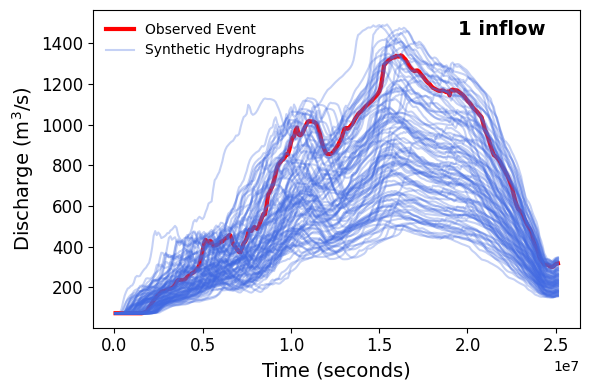

Gauge 1: Min Q = 72.39, Max Q = 1501.94


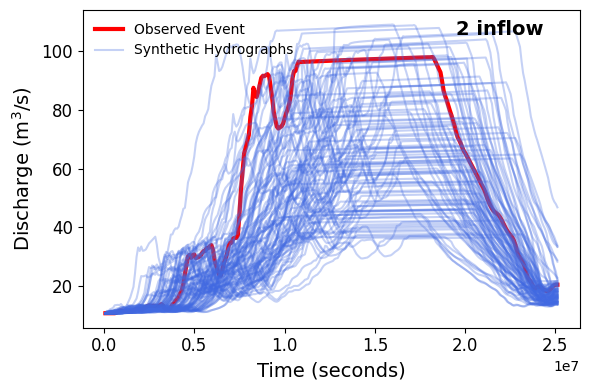

Gauge 2: Min Q = 10.89, Max Q = 109.61


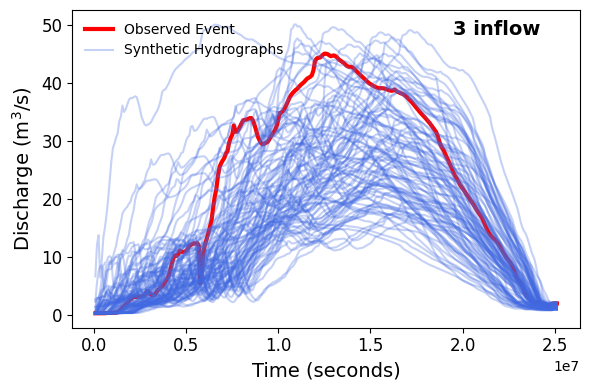

Gauge 3: Min Q = 0.22, Max Q = 50.49

GLOBAL STATS FOR ALL SAMPLES
Absolute Min Q: 0.22 m^3/s
Absolute Max Q: 1501.94 m^3/s


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def plot_all_samples_per_gauge(Q_syn_df_all, station_ids, max_plot=None, sec_tick_interval=None):
    """
    Plot synthetic hydrographs for each gauge.
    Uses the first sample as the "Observed Event" (red)
    and the rest as "Synthetic Hydrographs" (blue).

    Assumes Q_syn_df.index is time in SECONDS.
    """

    global_min = float('inf')
    global_max = float('-inf')

    for i, Q_syn_df in enumerate(Q_syn_df_all):
        sid = station_ids[i]

        # Ensure numeric index (seconds)
        if not np.issubdtype(Q_syn_df.index.dtype, np.number):
            Q_syn_df = Q_syn_df.copy()
            Q_syn_df.index = Q_syn_df.index.astype(float)

        # Update global statistics
        current_min = Q_syn_df.min().min()
        current_max = Q_syn_df.max().max()
        global_min = min(global_min, current_min)
        global_max = max(global_max, current_max)

        cols = list(Q_syn_df.columns)
        if max_plot is not None:
            cols = cols[:max_plot]

        if len(cols) == 0:
            continue

        obs_col = cols[0]
        syn_cols = cols[1:]

        plt.figure(figsize=(6, 4))

        # Observed Event
        plt.plot(Q_syn_df.index, Q_syn_df[obs_col],
                 color='red', linewidth=3, label='Observed Event')

        # Synthetic ensemble
        for j, col in enumerate(syn_cols):
            if j == 0:
                plt.plot(Q_syn_df.index, Q_syn_df[col],
                         color='royalblue', alpha=0.3, label='Synthetic Hydrographs')
            else:
                plt.plot(Q_syn_df.index, Q_syn_df[col],
                         color='royalblue', alpha=0.3)

        ax = plt.gca()

        # Optional custom tick spacing in seconds
        if sec_tick_interval is not None:
            xmin, xmax = ax.get_xlim()
            ticks = np.arange(0, xmax + sec_tick_interval, sec_tick_interval)
            ax.set_xticks(ticks)

        # In-plot label
        plt.text(0.75, 0.92, f"{sid} inflow",
                 transform=ax.transAxes,
                 fontsize=14,
                 fontweight='bold')

        plt.xlabel("Time (seconds)", fontsize=14)
        plt.ylabel("Discharge (m$^3$/s)", fontsize=14)
        plt.tick_params(axis='both', which='major', labelsize=12)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

        print(f"Gauge {sid}: Min Q = {current_min:.2f}, Max Q = {current_max:.2f}")

    print("\n" + "="*30)
    print("GLOBAL STATS FOR ALL SAMPLES")
    print(f"Absolute Min Q: {global_min:.2f} m^3/s")
    print(f"Absolute Max Q: {global_max:.2f} m^3/s")
    print("="*30)


# Execution
plot_all_samples_per_gauge(
    Q_syn_df_all,
    station_ids,
    max_plot=100
)


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset


def load_one_scenario_tms(base_dir, group_id, scenario_idx, station_ids):
    """
    Loads ONE scenario by index inside a group.

    Directory structure (UPDATED):
      base_dir/
        group_XXX/
          scenario_000000/
          scenario_000001/
          ...

    Parameters
    ----------
    base_dir : str
    group_id : int
        Group index (e.g. 0 -> group_000)
    scenario_idx : int
        Scenario index INSIDE the group (starts from 0)
    station_ids : list[int]

    Returns
    -------
    data : dict
        {station_id: (time_sec, discharge)}
    scen_name : str
        Folder name (e.g. 'scenario_000008')
    """

    group_dir = os.path.join(base_dir, f"group_{group_id:03d}")
    if not os.path.isdir(group_dir):
        raise FileNotFoundError(f"Group folder not found: {group_dir}")

    # discover scenario folders inside the group
    scenarios = sorted(
        d for d in os.listdir(group_dir)
        if d.startswith("scenario_")
    )

    if len(scenarios) == 0:
        raise RuntimeError(f"No scenarios found in {group_dir}")

    if scenario_idx < 0 or scenario_idx >= len(scenarios):
        raise IndexError(
            f"scenario_idx={scenario_idx} out of range (0–{len(scenarios)-1})"
        )

    scen_name = scenarios[scenario_idx]
    scen_dir = os.path.join(group_dir, scen_name)

    data = {}
    for sid in station_ids:
        fpath = os.path.join(scen_dir, f"tms_files/{sid}.tms")
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing .tms file: {fpath}")

        with Dataset(fpath, "r") as ds:
            t = np.asarray(ds.variables["time"][:], dtype=float)
            q = np.asarray(ds.variables["discharge"][:], dtype=float)

        data[str(sid)] = (t, q)

    return data, scen_name
def plot_scenario_hgs(data, title=None, time_unit="hours"):
    """
    data : dict {station_id: (time_sec, discharge)}
    """
    plt.figure(figsize=(11, 5))

    for sid, (t, q) in data.items():
        if time_unit == "hours":
            x = t / 3600.0
            xlabel = "Time (hours)"
        elif time_unit == "days":
            x = t / (24.0 * 3600.0)
            xlabel = "Time (days)"
        else:
            x = t
            xlabel = "Time (seconds)"

        plt.plot(x, q, label=str(sid), alpha=0.9)

    plt.xlabel(xlabel)
    plt.ylabel("Discharge (m$^3$/s)")
    plt.grid(True, alpha=0.3)
    if title is not None:
        plt.title(title)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


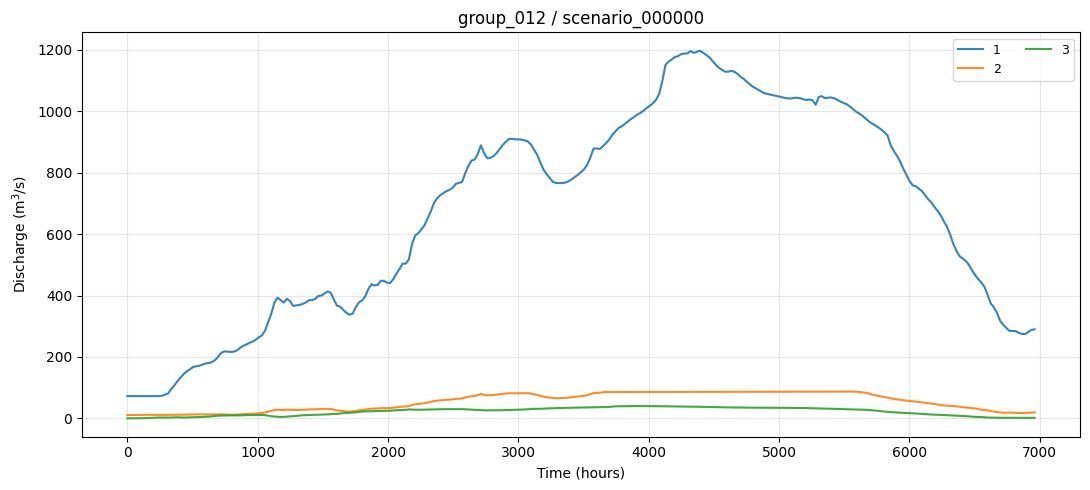

In [8]:
station_ids = [
    1, 2, 3
]

base_dir = "/storage/group/cxs1024/default/mehdi/chowilla_river_scenario_groups/scenario_groups_2"
group_id = 12       # group_000
scenario_idx = 0    # scenario_000008 INSIDE group_000

data, scen_name = load_one_scenario_tms(
    base_dir,
    group_id,
    scenario_idx,
    station_ids
)

plot_scenario_hgs(
    data,
    title=f"group_{group_id:03d} / {scen_name}",
    time_unit="hours"
)


In [ ]:
scenario_idx = 2    # scenario_000008 INSIDE group_000

data, scen_name = load_one_scenario_tms(
    base_dir,
    group_id,
    scenario_idx,
    station_ids
)

plot_scenario_hgs(
    data,
    title=f"group_{group_id:03d} / {scen_name}",
    time_unit="hours"
)
